### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import MODEL_DATA_PATH

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Model data:")
print(MODEL_DATA_PATH)

Model data:
/media/breezy/NewVolume/projects_int/dengue/data/gold/dengue_modeling.parquet


### Load the modeling dataset

In [2]:
df = pd.read_parquet(
    MODEL_DATA_PATH
)

df = df.sort_values(
    ["district", "week_start"]
).reset_index(drop=True)

print("Shape:", df.shape)

Shape: (26416, 17)


### Basic dataset profile

In [3]:
print("=" * 70)
print("DATASET PROFILE")
print("=" * 70)

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
print("Districts:", df["district"].nunique())
print("Start:", df["week_start"].min())
print("End:", df["week_start"].max())

DATASET PROFILE
Rows: 26,416
Columns: 17
Districts: 26
Start: 2007-01-01 00:00:00
End: 2026-06-29 00:00:00


In [4]:
print("datatypes \n",df.dtypes)

datatypes 
 district                             str
year                               int64
week                               int64
week_start                datetime64[us]
cases                              Int64
is_missing_observation              bool
rainfall_mm                      float64
temperature_mean                 float64
temperature_max                  float64
temperature_min                  float64
humidity_mean                    float64
wind_speed_mean                  float64
dtr_mean                         float64
weather_days                       int64
weather_complete                    bool
weather_missing_days               int64
week_gap_days                    float64
dtype: object


### Zero and missing cases

In [5]:
target_summary = {
    "total_rows": len(df),
    "missing_cases": df["cases"].isna().sum(),
    "zero_cases": (df["cases"] == 0).sum(),
    "positive_cases": (df["cases"] > 0).sum(),
}

for key, value in target_summary.items():
    print(f"{key.capitalize():20}: {value}")

Total_rows          : 26416
Missing_cases       : 26
Zero_cases          : 3623
Positive_cases      : 22767


In [6]:
total = len(df)

print(
    "Missing:",
    f"{df['cases'].isna().mean() * 100:.2f}%"
)

print(
    "Zero:",
    f"{(df['cases'] == 0).mean() * 100:.2f}%"
)

print(
    "Positive:",
    f"{(df['cases'] > 0).mean() * 100:.2f}%"
)

Missing: 0.10%
Zero: 13.73%
Positive: 86.27%


there is small missing case because of 3 pdf are missing so this is missing the 79 cases

### Target distribution

### Histogram

In [7]:
print("max value of cases :", df["cases"].max())
print("min value of cases :", df["cases"].min())

max value of cases : 2631
min value of cases : 0


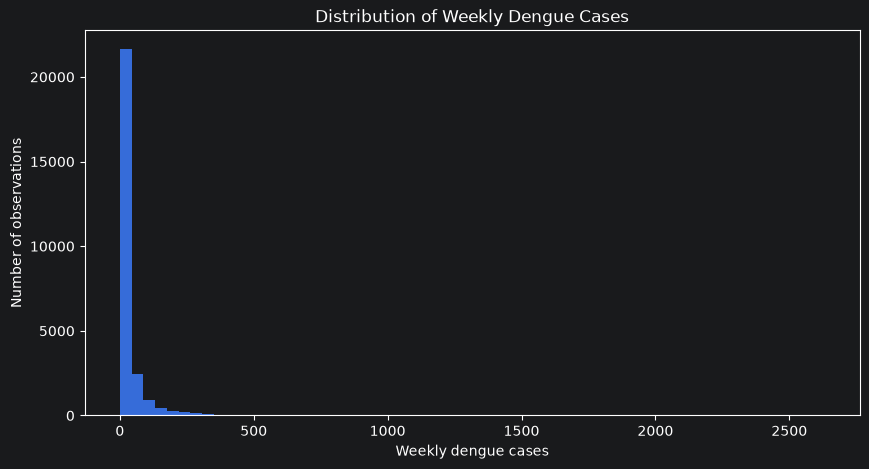

In [8]:
plt.figure(figsize=(10, 5))

df["cases"].dropna().plot(
    kind="hist",
    bins=60,
)

plt.xlabel("Weekly dengue cases")
plt.ylabel("Number of observations")
plt.title("Distribution of Weekly Dengue Cases")

plt.show()

max value of cases : 2631 \
min value of cases : 0

### Log-scale distribution

In [9]:
log_cases = np.log1p(df["cases"].dropna())

print("Original min cases:", df["cases"].min())
print("Original max cases:", df["cases"].max())

print("Log1p min:", log_cases.min())
print("Log1p max:", log_cases.max())

Original min cases: 0
Original max cases: 2631
Log1p min: 0.0
Log1p max: 7.875499292445208


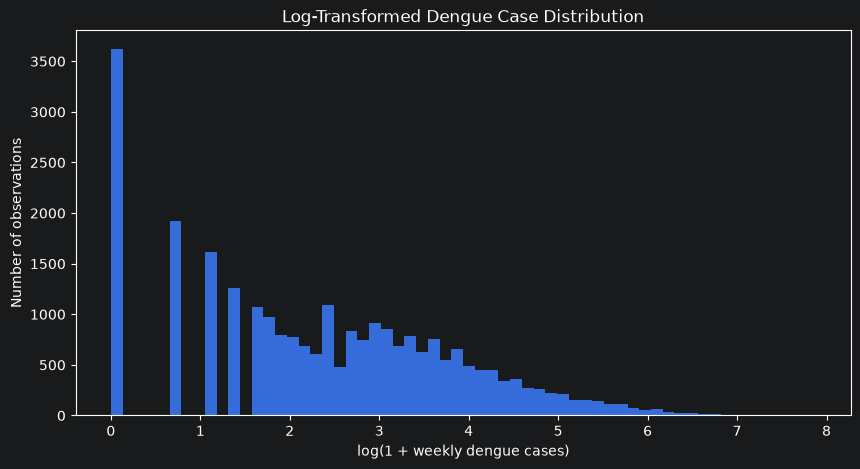

In [10]:
plt.figure(figsize=(10, 5))

np.log1p(
    df["cases"].dropna()
).plot(
    kind="hist",
    bins=60,
)

plt.xlabel("log(1 + weekly dengue cases)")
plt.ylabel("Number of observations")
plt.title("Log-Transformed Dengue Case Distribution")

plt.show()

### District statistics

In [11]:
district_stats = (
    df.groupby("district")["cases"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
        total="sum",
    )
    .sort_values("mean",ascending=False)
)

district_stats

,observations,mean,median,std,minimum,maximum,total
district,,,,,,,
Colombo,1015,182.178325,130.0,207.290786,0,1972,184911
Gampaha,1015,108.95468,58.0,198.690585,0,2631,110589
Kandy,1015,68.363547,39.0,103.104124,0,1062,69389
Kalutara,1015,51.621675,32.0,72.421914,0,703,52396
Jaffna,1015,45.197044,18.0,90.863785,0,931,45875
Kurunegala,1015,43.032512,26.0,63.428911,0,681,43678
Ratnapura,1015,42.609852,26.0,66.426432,0,920,43249
Kegalle,1015,35.883744,21.0,66.982837,0,834,36422
Galle,1015,34.517241,17.0,51.555158,0,742,35035


### Average dengue cases by district

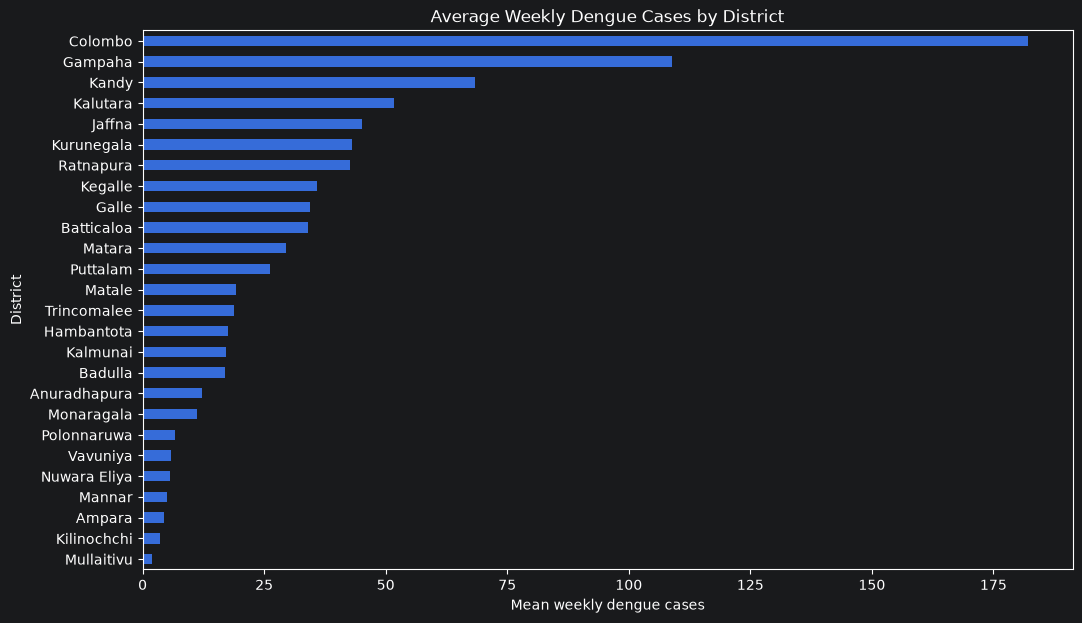

In [12]:
plt.figure(figsize=(12, 7))

district_stats["mean"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Mean weekly dengue cases")
plt.ylabel("District")
plt.title("Average Weekly Dengue Cases by District")

plt.show()

the largest values is come from the colombo and gamapaha

### Total dengue burden by district

In [13]:
district_totals = (
    df.groupby("district")["cases"]
    .sum()
    .sort_values(
        ascending=False
    )
)

district_totals

district
Colombo         184911
Gampaha         110589
Kandy            69389
Kalutara         52396
Jaffna           45875
Kurunegala       43678
Ratnapura        43249
Kegalle          36422
Galle            35035
Batticaloa       34459
Matara           30002
Puttalam         26585
Matale           19464
Trincomalee      19144
Hambantota       17854
Kalmunai         17507
Badulla          17291
Anuradhapura     12334
Monaragala       11404
Polonnaruwa       6859
Vavuniya          5945
Nuwara Eliya      5742
Mannar            5101
Ampara            4482
Kilinochchi       3536
Mullaitivu        1974
Name: cases, dtype: Int64

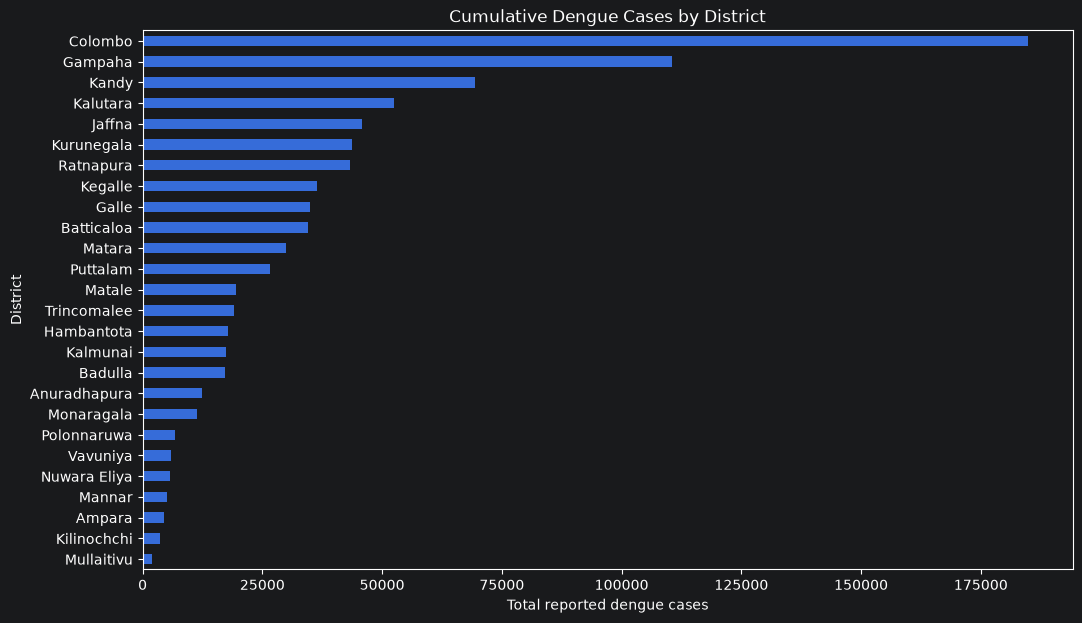

In [14]:
plt.figure(figsize=(12, 7))

district_totals.sort_values().plot(
    kind="barh"
)

plt.xlabel("Total reported dengue cases")
plt.ylabel("District")
plt.title("Cumulative Dengue Cases by District")

plt.show()

### Temporal dengue trend

### National weekly cases

In [15]:
national_weekly = (
    df.groupby("week_start")["cases"]
    .sum()
    .sort_index()
)

national_weekly

week_start
2007-01-01     167
2007-01-08     181
2007-01-15     163
2007-01-22     131
2007-01-29     144
              ... 
2026-06-01    2088
2026-06-08    2832
2026-06-15    3973
2026-06-22    5828
2026-06-29    5828
Name: cases, Length: 1016, dtype: Int64

the highest number of the cases report in 2017 july - August after that 2021 Jan and next 2026 June

### Plot national trend

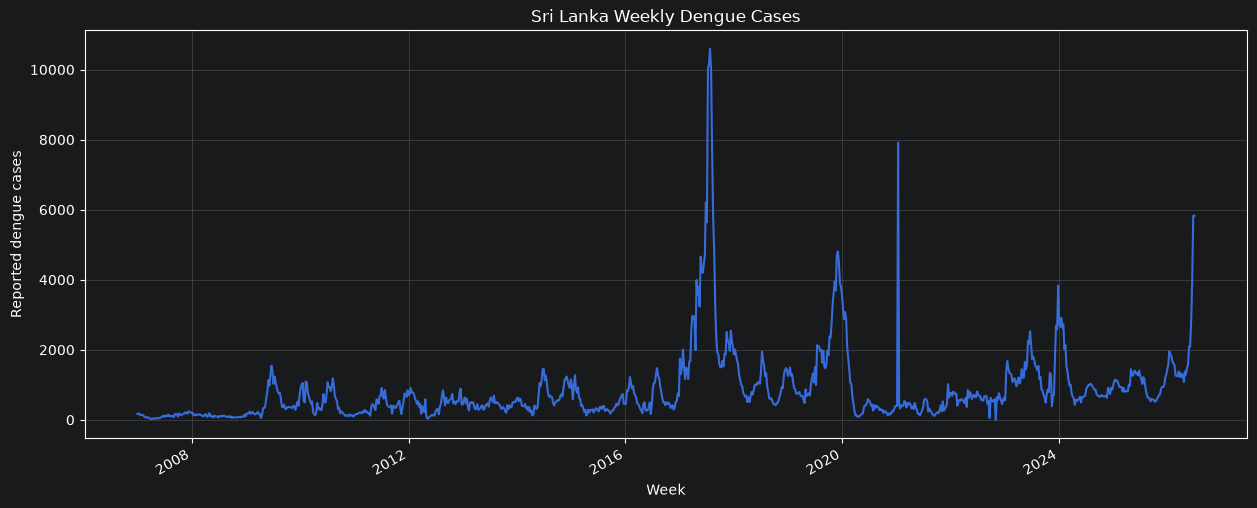

In [16]:
plt.figure(figsize=(15, 6))

national_weekly.plot()

plt.xlabel("Week")
plt.ylabel("Reported dengue cases")
plt.title("Sri Lanka Weekly Dengue Cases")

plt.grid(True, alpha=0.3)

plt.show()

there see this 017 july - August after that 2021 Jan and next 2026 June

### Smoothed dengue trend

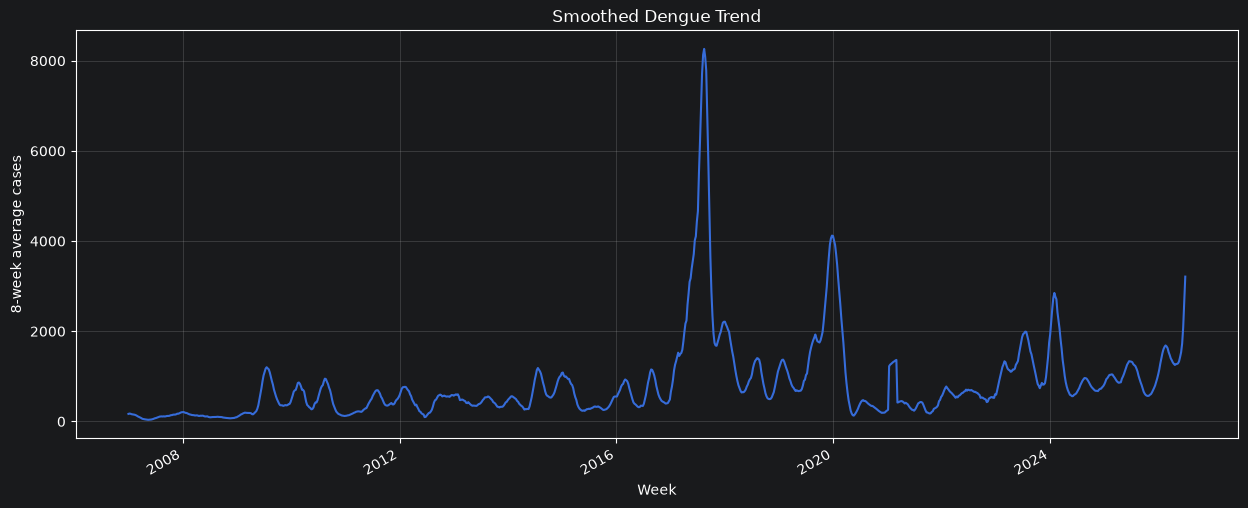

In [17]:
national_rolling = (
    national_weekly
    .rolling(
        window=8,
        min_periods=1,
    )
    .mean()
)

plt.figure(figsize=(15, 6))

national_rolling.plot()

plt.xlabel("Week")
plt.ylabel("8-week average cases")
plt.title("Smoothed Dengue Trend")

plt.grid(True, alpha=0.3)

plt.show()

### Seasonality

### Cases by epidemiological week

In [18]:
seasonality = (
    df.groupby("week")["cases"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
    )
)

seasonality

,mean,median,maximum
week,,,
1,38.828846,13.0,746
2,54.980769,18.0,990
3,41.944231,14.0,805
4,40.623077,14.0,595
5,40.626923,15.0,746
6,34.467308,13.0,483
7,32.136538,12.0,418
8,29.996154,13.0,444
9,26.542308,12.0,347


mostly jan (mid of jan) is the peak. and most of the july. jan> july

### Median seasonal pattern

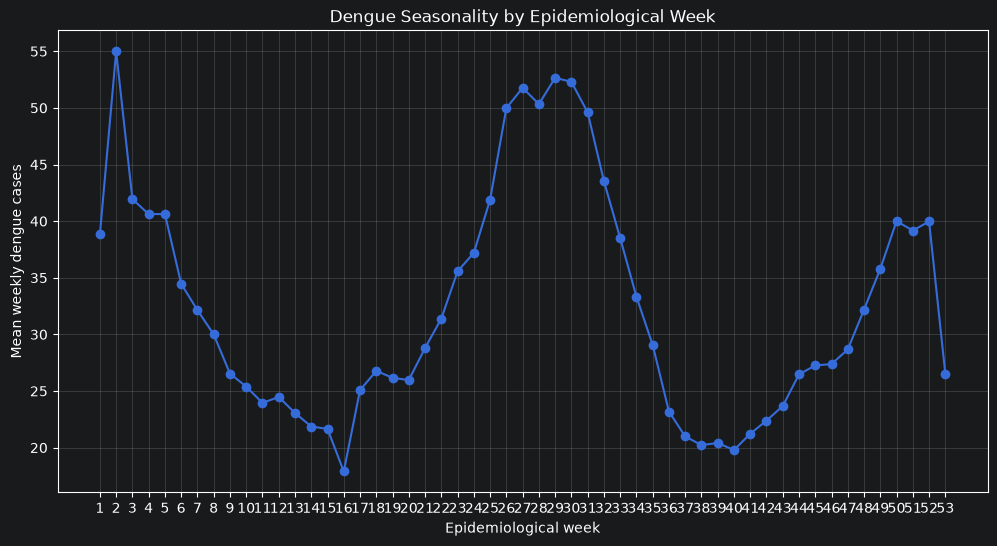

In [19]:
plt.figure(figsize=(12, 6))

seasonality["mean"].plot(
    marker="o"
)

plt.xlabel("Epidemiological week")
plt.ylabel("Mean weekly dengue cases")
plt.title("Dengue Seasonality by Epidemiological Week")

plt.xticks(
    range(
        1,
        int(df["week"].max()) + 1,
    )
)

plt.grid(True, alpha=0.3)

plt.show()

In [20]:
year_week = (
    df.groupby(
        ["year", "week"]
    )["cases"]
    .sum()
    .reset_index()
)

heatmap_data = year_week.pivot(
    index="year",
    columns="week",
    values="cases",
)

heatmap_data

week,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007,167,181,163,131,144,144,108,75,72,59,75,61,35,22,38,31,45,27,34,55,47,42,61,80,95,118,81,110,129,101,147,97,110,97,115,78,166,159,160,92,185,157,131,148,169,176,213,202,171,235,236,221,<NA>
2008,190,200,136,125,155,139,145,150,156,131,124,105,103,154,155,82,103,189,110,128,78,69,119,100,104,89,63,111,107,87,119,112,105,98,89,78,102,78,97,51,75,73,67,60,78,76,76,73,85,96,85,146,<NA>
2009,100,179,181,188,238,170,200,222,179,151,166,188,226,166,148,52,167,334,335,396,637,808,1135,978,1300,1545,1340,1023,1238,1058,928,810,750,768,609,375,362,435,320,306,348,370,361,368,343,336,398,383,288,414,519,400,689
2010,903,997,1053,539,498,1094,1055,770,663,549,456,524,226,155,134,213,483,320,340,281,278,414,732,516,491,736,1073,930,936,819,934,1182,977,667,597,532,307,343,185,238,224,171,157,115,114,130,109,153,117,141,108,94,<NA>
2011,136,160,169,167,199,212,202,181,246,223,280,215,232,188,184,117,366,442,433,347,275,579,576,453,670,692,909,692,605,851,671,443,395,370,360,411,174,402,391,334,358,430,495,547,315,166,360,507,755,699,653,842,<NA>
2012,704,734,906,779,779,745,611,546,453,530,373,454,171,391,255,220,587,98,34,47,88,109,130,144,116,129,254,296,314,157,362,460,678,840,647,412,638,512,477,556,581,613,735,469,526,445,512,542,522,786,890,435,<NA>
2013,439,549,635,468,607,379,265,479,504,481,502,384,301,331,442,285,310,331,398,415,284,321,409,448,468,376,551,638,588,505,690,477,478,506,474,441,406,312,338,363,311,231,200,418,311,414,354,366,498,496,522,514,<NA>
2014,613,634,530,607,562,395,388,388,450,325,369,264,370,223,268,128,154,410,357,311,340,697,1048,956,1136,1448,1450,1130,1259,1050,766,654,696,650,642,483,410,486,526,557,545,576,675,731,670,892,1138,1168,1237,1104,998,911,<NA>
2015,1152,970,587,976,1275,884,774,921,615,603,395,430,333,229,289,123,184,292,213,277,282,296,210,260,334,317,273,240,372,365,308,393,389,247,286,307,271,250,174,234,260,276,350,368,466,417,444,568,639,694,738,460,<NA>


In [21]:
heatmap_data_cp = heatmap_data.copy()
heatmap_data_cp.dropna(axis=0, how="all", inplace=True)
heatmap_array = heatmap_data.to_numpy(dtype=float)
heatmap_array

array([[ 167.,  181.,  163., ...,  236.,  221.,   nan],
       [ 190.,  200.,  136., ...,   85.,  146.,   nan],
       [ 100.,  179.,  181., ...,  519.,  400.,  689.],
       ...,
       [2760., 2656., 2913., ...,  915.,  860.,   nan],
       [ 969., 1118., 1148., ..., 1201., 1276.,   nan],
       [1443., 1569., 1957., ...,   nan,   nan,   nan]], shape=(20, 53))

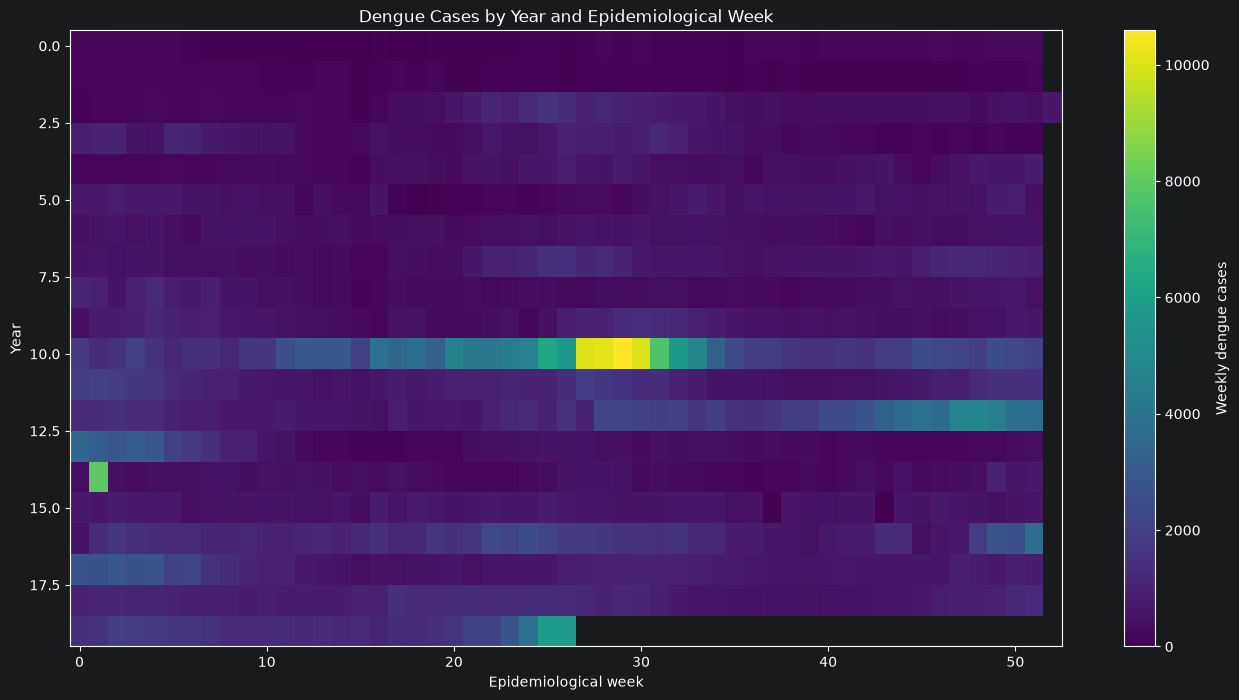

In [22]:

plt.figure(figsize=(16, 8))

plt.imshow(
    heatmap_array,
    aspect="auto",
    interpolation="nearest",
)

plt.colorbar(label="Weekly dengue cases")

plt.xlabel("Epidemiological week")
plt.ylabel("Year")
plt.title("Dengue Cases by Year and Epidemiological Week")

plt.show()

### District × time behavior

In [23]:
top_districts = (
    district_stats
    .sort_values(
        "mean",
        ascending=False,
    )
    .head(5)
    .index
)

top_districts

Index(['Colombo', 'Gampaha', 'Kandy', 'Kalutara', 'Jaffna'], dtype='str', name='district')

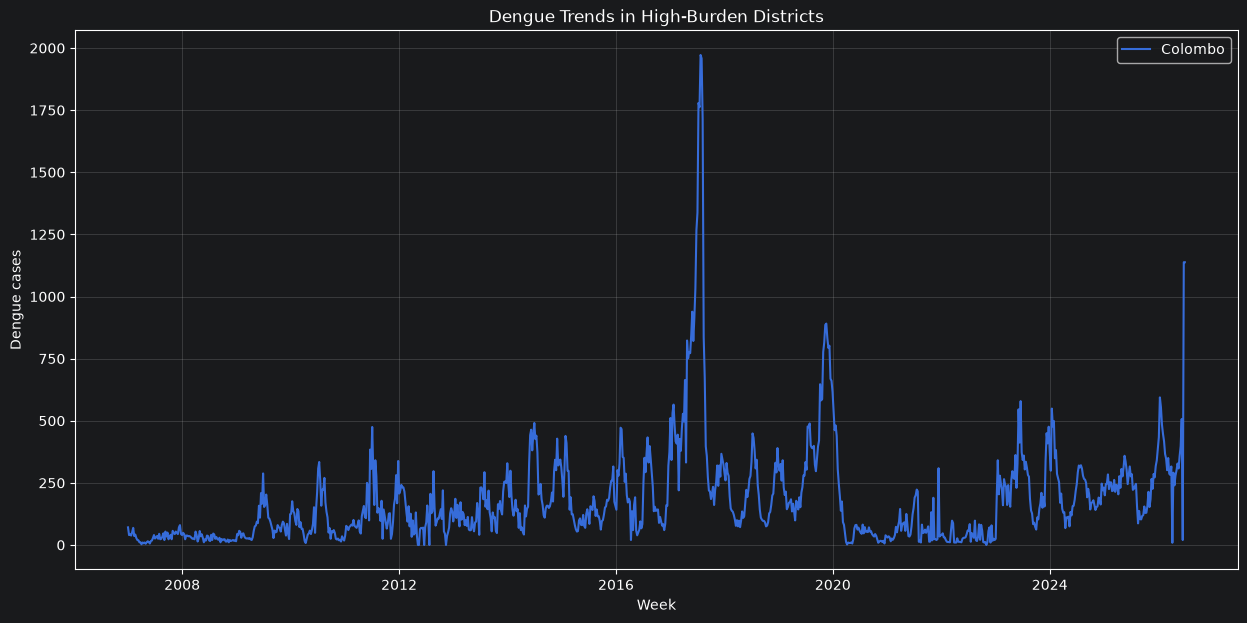

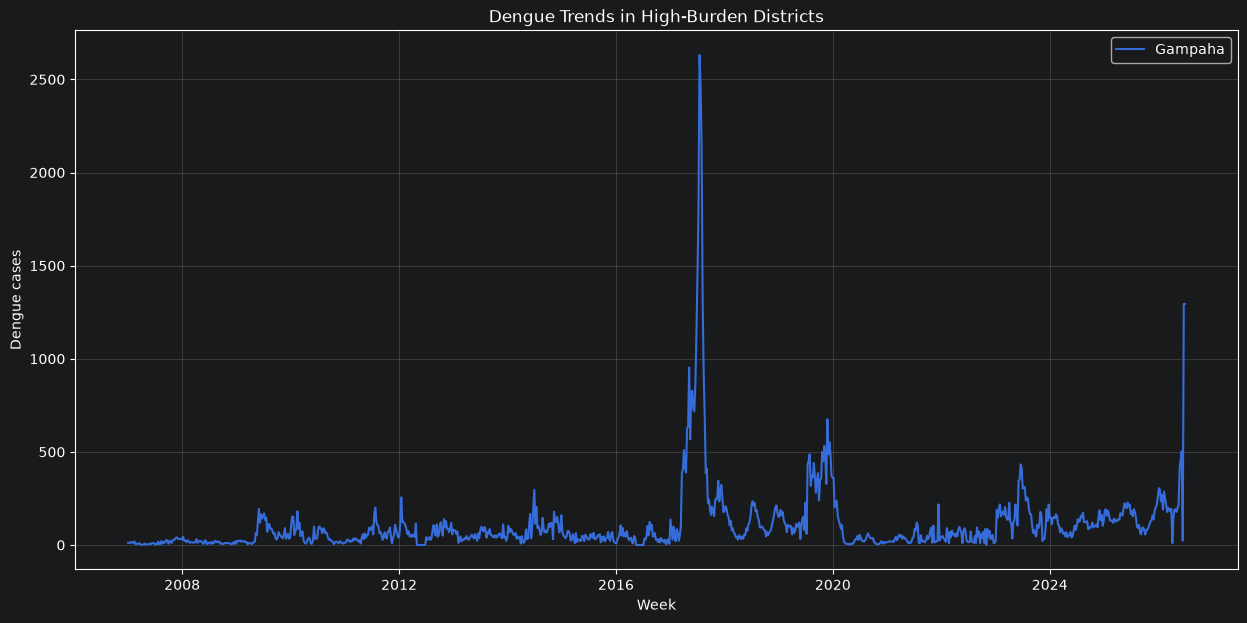

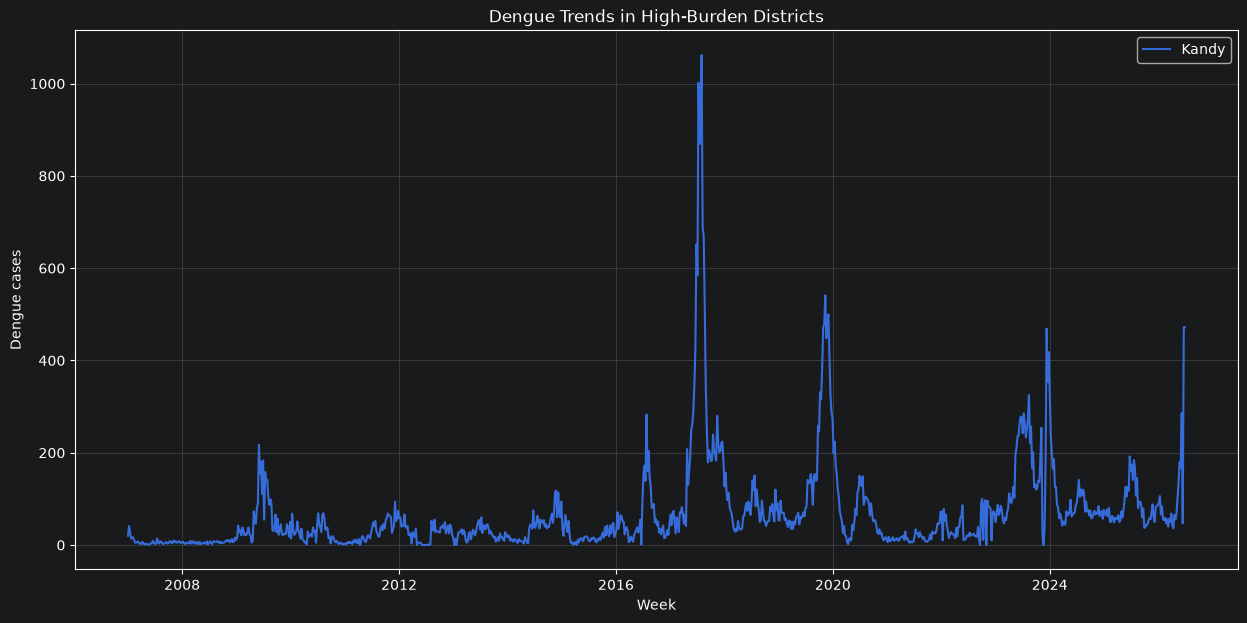

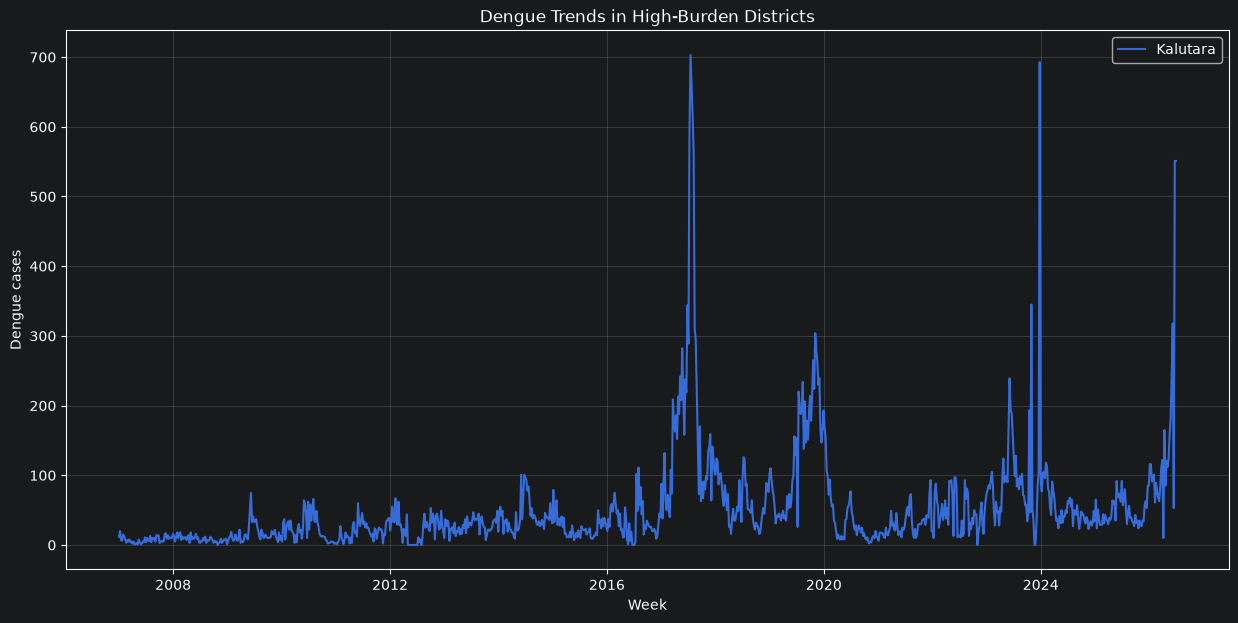

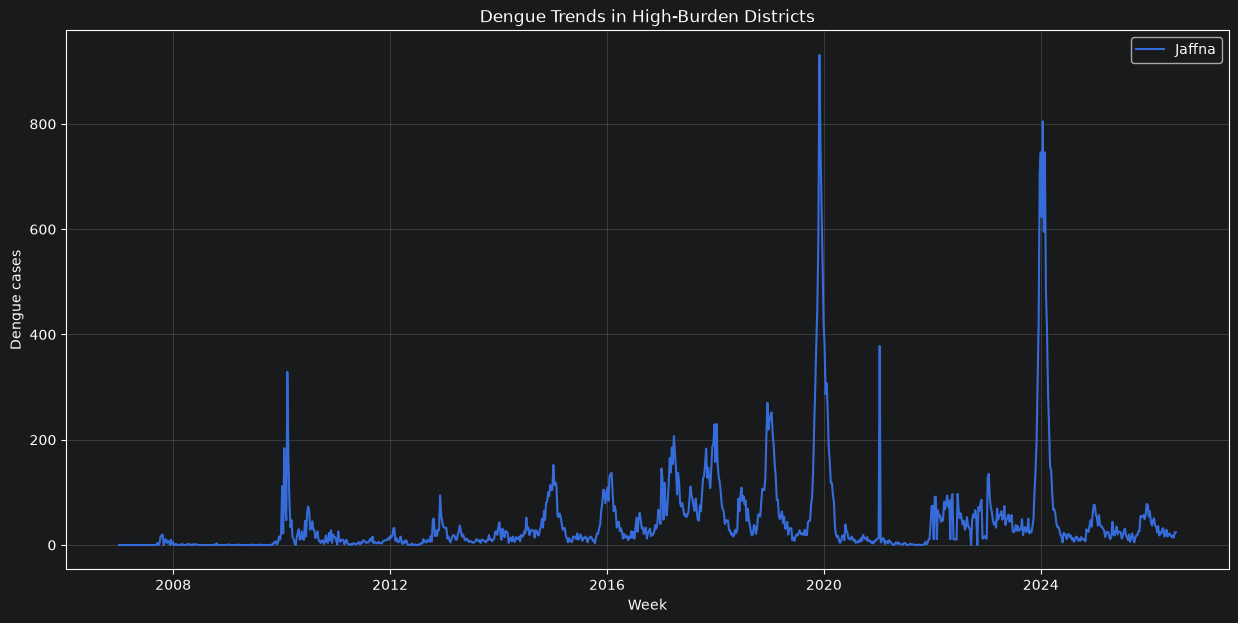

In [24]:


for district in top_districts:
    plt.figure(figsize=(15, 7))
    district_series = (
        df[
            df["district"] == district
        ]
        .groupby("week_start")["cases"]
        .sum()
    )

    plt.plot(
        district_series.index,
        district_series.values,
        label=district,
    )


    plt.xlabel("Week")
    plt.ylabel("Dengue cases")
    plt.title("Dengue Trends in High-Burden Districts")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.show()

in jaffna shows 2020 is the peak and also , other several districts peak is 2017

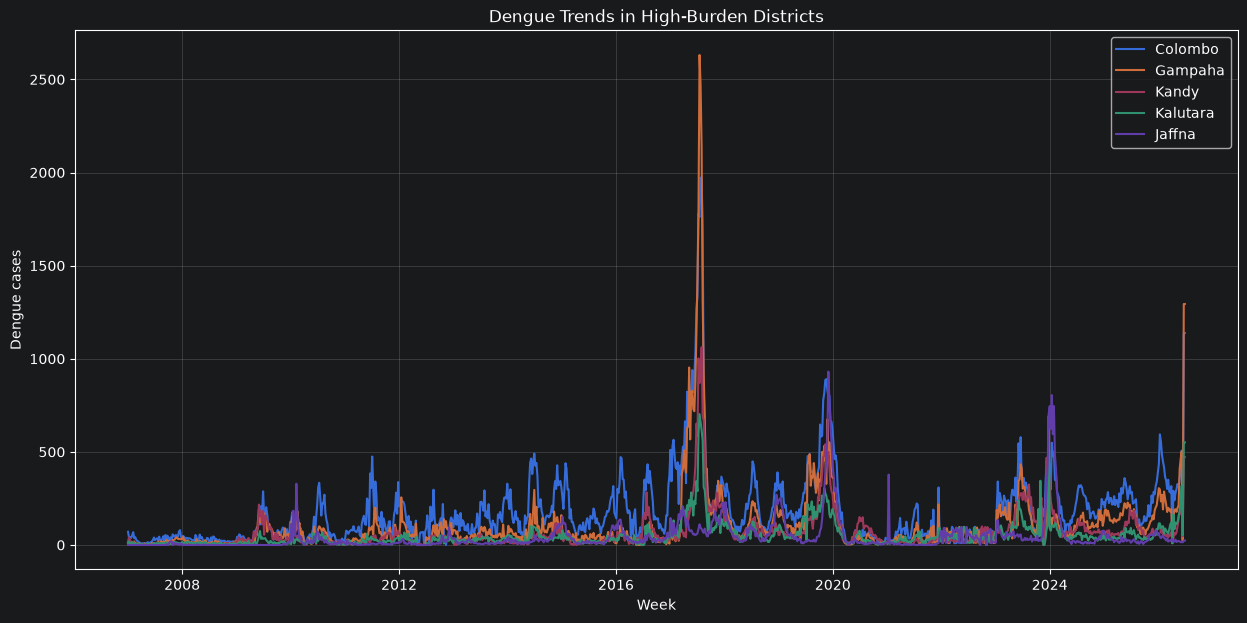

In [25]:
plt.figure(figsize=(15, 7))

for district in top_districts:

    district_series = (
        df[
            df["district"] == district
        ]
        .groupby("week_start")["cases"]
        .sum()
    )

    plt.plot(
        district_series.index,
        district_series.values,
        label=district,
    )

plt.xlabel("Week")
plt.ylabel("Dengue cases")
plt.title("Dengue Trends in High-Burden Districts")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

### Dengue persistence

In [26]:
national = (
    df.groupby("week_start")["cases"]
    .sum()
    .sort_index()
)

for lag in [1, 2, 3, 4, 8, 12]:
    correlation = (
        national
        .corr(
            national.shift(lag)
        )
    )

    print(
        f"Lag {lag:2d}: "
        f"{correlation:.4f}"
    )

Lag  1: 0.9129
Lag  2: 0.8704
Lag  3: 0.8099
Lag  4: 0.7462
Lag  8: 0.5320
Lag 12: 0.4019


### District-level autocorrelation

In [27]:
district_autocorrelation = []

for district, group in df.groupby(
    "district"
):

    series = (
        group
        .sort_values("week_start")
        ["cases"]
    )

    district_autocorrelation.append(
        {
            "district": district,
            "lag_1": series.corr(
                series.shift(1)
            ),
            "lag_2": series.corr(
                series.shift(2)
            ),
            "lag_4": series.corr(
                series.shift(4)
            ),
        }
    )

autocorr_df = pd.DataFrame(
    district_autocorrelation
).sort_values(
    "lag_1",
    ascending=False,
)

autocorr_df

,district,lag_1,lag_2,lag_4
3,Batticaloa,0.940212,0.886371,0.780007
24,Trincomalee,0.932173,0.874676,0.713902
11,Kandy,0.927727,0.893001,0.759125
8,Jaffna,0.921745,0.869918,0.706612
4,Colombo,0.921591,0.875251,0.750964
6,Gampaha,0.919485,0.844284,0.683854
14,Kurunegala,0.871113,0.839497,0.740000
22,Puttalam,0.865826,0.823512,0.719158
17,Matara,0.825641,0.782091,0.662046
7,Hambantota,0.808518,0.754801,0.649115


### Outbreak detection exploration

In [28]:
q90 = df["cases"].quantile(0.90)
q95 = df["cases"].quantile(0.95)
q99 = df["cases"].quantile(0.99)

print("90th percentile:", q90)
print("95th percentile:", q95)
print("99th percentile:", q99)

90th percentile: 77
95th percentile: 137
99th percentile: 362


In [29]:
print(
    "Above 90th:",
    (df["cases"] > q90).sum()
)

print(
    "Above 95th:",
    (df["cases"] > q95).sum()
)

print(
    "Above 99th:",
    (df["cases"] > q99).sum()
)

Above 90th: 2610
Above 95th: 1314
Above 99th: 261


### Largest dengue observations

In [30]:
largest_events = (
    df[
        [
            "district",
            "week_start",
            "year",
            "week",
            "cases",
        ]
    ]
    .sort_values(
        "cases",
        ascending=False,
    )
    .head(30)
)

largest_events

,district,week_start,year,week,cases
6645,Gampaha,2017-07-17,2017,29,2631
6646,Gampaha,2017-07-24,2017,30,2471
6647,Gampaha,2017-07-31,2017,31,2135
4614,Colombo,2017-07-24,2017,30,1972
4615,Colombo,2017-07-31,2017,31,1958
6644,Gampaha,2017-07-10,2017,28,1802
4612,Colombo,2017-07-10,2017,28,1779
4613,Colombo,2017-07-17,2017,29,1762
4616,Colombo,2017-08-07,2017,32,1713
6643,Gampaha,2017-07-03,2017,27,1444


### Weather analysis

In [31]:
weather_columns = [
    "rainfall_mm",
    "temperature_mean",
    "temperature_max",
    "temperature_min",
    "humidity_mean",
    "wind_speed_mean",
    "dtr_mean",
]

df[weather_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
rainfall_mm,26416.0,36.167229,43.711617,0.000000,6.470000,22.320000,49.250000,611.310000
temperature_mean,26416.0,26.584391,1.906726,19.028571,25.431429,26.688571,27.998571,31.705714
temperature_max,26416.0,29.500986,2.024515,23.162857,28.070000,29.122857,30.794286,39.807143
temperature_min,26416.0,24.406773,2.480783,14.010000,22.664286,24.971429,26.362857,29.994286
humidity_mean,26416.0,81.533065,6.045807,54.371429,77.451429,82.135714,86.148571,96.085714
wind_speed_mean,26416.0,4.530876,1.784514,1.018571,3.125714,4.302857,5.774643,11.454286
dtr_mean,26416.0,5.094212,2.596227,0.652857,2.928214,4.762857,6.807143,18.004286


### Weather correlation with dengue

In [32]:
correlations = (
    df[
        ["cases"] + weather_columns
    ]
    .corr()["cases"]
    .sort_values(
        ascending=False
    )
)

print(correlations)

cases               1.000000
humidity_mean       0.105569
rainfall_mm         0.019062
wind_speed_mean     0.011828
temperature_min    -0.011914
temperature_mean   -0.045450
dtr_mean           -0.053499
temperature_max    -0.083212
Name: cases, dtype: float64


In [33]:
for col in weather_columns:
    for lag in [1, 2, 3, 4, 6, 8]:
        df[f"{col}_lag_{lag}"] = (
            df.groupby("district")[col]
            .shift(lag)
        )

In [34]:
results = []

lags = [1, 2, 3, 4, 6, 8]

for district, group in df.groupby("district"):

    for col in weather_columns:
        for lag in lags:

            correlation = (
                group["cases"]
                .corr(group[f"{col}_lag_{lag}"])
            )

            results.append({
                "district": district,
                "weather": col,
                "lag": lag,
                "correlation": correlation
            })

weather_lag_correlations = pd.DataFrame(results)

print(weather_lag_correlations)

      district      weather  lag  correlation
0       Ampara  rainfall_mm    1     0.007368
1       Ampara  rainfall_mm    2     0.068627
2       Ampara  rainfall_mm    3     0.028948
3       Ampara  rainfall_mm    4    -0.019188
4       Ampara  rainfall_mm    6    -0.004301
...        ...          ...  ...          ...
1087  Vavuniya     dtr_mean    2    -0.138176
1088  Vavuniya     dtr_mean    3    -0.140826
1089  Vavuniya     dtr_mean    4    -0.142981
1090  Vavuniya     dtr_mean    6    -0.135451
1091  Vavuniya     dtr_mean    8    -0.085370

[1092 rows x 4 columns]


these weather features just because correlations are low. this use in model traing i think \
rainfall + humidity + temperature + season + previous cases. <br>
↓ <br>
dengue

### Missingness analysis

In [35]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (
        df.isna().mean() * 100
    ),
})

missing_summary.sort_values(
    "missing_pct",
    ascending=False,
)

,missing_count,missing_pct
rainfall_mm_lag_8,208,0.787402
temperature_max_lag_8,208,0.787402
temperature_mean_lag_8,208,0.787402
humidity_mean_lag_8,208,0.787402
temperature_min_lag_8,208,0.787402
dtr_mean_lag_8,208,0.787402
wind_speed_mean_lag_8,208,0.787402
temperature_max_lag_6,156,0.590551
temperature_min_lag_6,156,0.590551
rainfall_mm_lag_6,156,0.590551


### Missing dengue observations over time

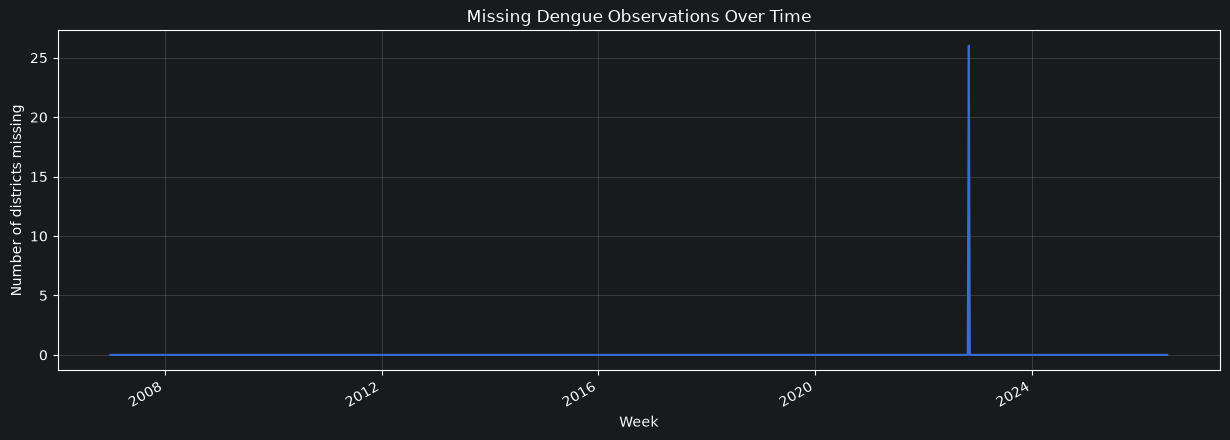

In [36]:
missing_weekly = (
    df.groupby("week_start")
    ["is_missing_observation"]
    .sum()
)

plt.figure(figsize=(15, 5))

missing_weekly.plot()

plt.xlabel("Week")
plt.ylabel("Number of districts missing")
plt.title(
    "Missing Dengue Observations Over Time"
)

plt.grid(True, alpha=0.3)

plt.show()

missing 3 week of dengue 2015w31 2021w43 2022w44

### Missing weather observations

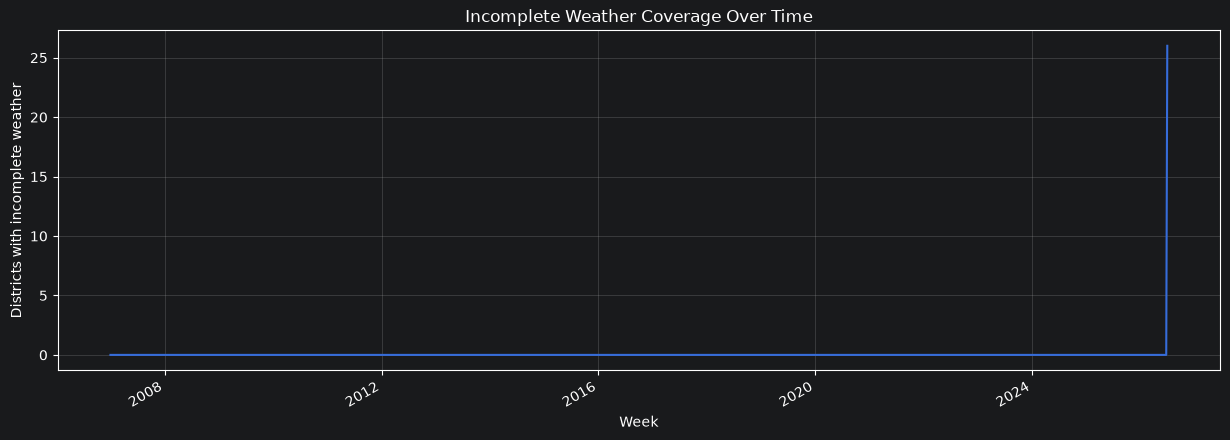

In [37]:
weather_missing_weekly = (
    df.groupby("week_start")
    ["weather_complete"]
    .apply(
        lambda x: (~x).sum()
    )
)

plt.figure(figsize=(15, 5))

weather_missing_weekly.plot()

plt.xlabel("Week")
plt.ylabel("Districts with incomplete weather")
plt.title(
    "Incomplete Weather Coverage Over Time"
)

plt.grid(True, alpha=0.3)

plt.show()

this was not a issue becasue still have the data for weather aug 20 becasue today is aug 20

### Check whether districts have different seasonal patterns

In [38]:
district_week = (
    df.groupby(
        [
            "district",
            "week",
        ]
    )["cases"]
    .mean()
    .reset_index()
)

district_week

,district,week,cases
0,Ampara,1,3.65
1,Ampara,2,38.45
2,Ampara,3,4.5
3,Ampara,4,4.1
4,Ampara,5,7.05
...,...,...,...
1373,Vavuniya,49,10.157895
1374,Vavuniya,50,11.368421
1375,Vavuniya,51,17.315789
1376,Vavuniya,52,16.789474


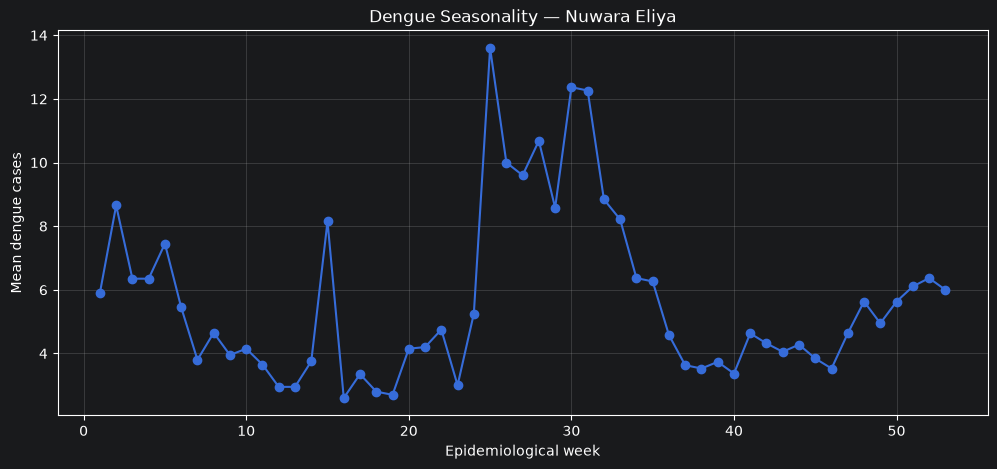

In [39]:
example_district = (
    district_stats.index[21]
)

example = district_week[
    district_week["district"]
    == example_district
]

plt.figure(figsize=(12, 5))

plt.plot(
    example["week"],
    example["cases"],
    marker="o",
)

plt.xlabel("Epidemiological week")
plt.ylabel("Mean dengue cases")
plt.title(
    f"Dengue Seasonality — {example_district}"
)

plt.grid(True, alpha=0.3)

plt.show()

### final audit

In [40]:
print("=" * 70)
print("EDA COMPLETE")
print("=" * 70)

print(
    f"Observations: {len(df):,}"
)

print(
    f"Districts: {df['district'].nunique()}"
)

print(
    f"Date range: "
    f"{df['week_start'].min().date()} "
    f"→ "
    f"{df['week_start'].max().date()}"
)

print(
    f"Missing dengue observations: "
    f"{df['cases'].isna().sum():,}"
)

print(
    f"Zero dengue observations: "
    f"{(df['cases'] == 0).sum():,}"
)

print(
    f"Maximum weekly district cases: "
    f"{df['cases'].max():,.0f}"
)

EDA COMPLETE
Observations: 26,416
Districts: 26
Date range: 2007-01-01 → 2026-06-29
Missing dengue observations: 26
Zero dengue observations: 3,623
Maximum weekly district cases: 2,631
